In [3]:
'''
1. VImoistureDivergence
2. VIwater
3. CloudCover
4. EvaporationRate
5. SkinTemperature
6. SeaLevelPressure
7. 10mWindSpeed
'''

'\n1. VImoistureDivergence\n2. VIwater\n3. CloudCover\n4. EvaporationRate\n5. SkinTemperature\n6. SeaLevelPressure\n7. 10mWindSpeed\n'

In [4]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [5]:
# %%
DATA_DIR = Path("/Users/camus/Desktop/dissertation/meeting1/RainfallWestAfrica_Resources")
runid = "ERA5"

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [6]:
# %%
def load_npy(name):
    path = DATA_DIR / f"{runid}_{name}_regr_onescale.npy"
    arr = np.load(path).astype(np.float32)
    print(
        f"{name:25s}",
        "shape:", arr.shape,
        "min:", arr.min(),
        "max:", arr.max(),
        "NaN:", np.isnan(arr).sum()
    )
    return arr

In [7]:
# ## 1. Load Data

In [8]:
# %%
precip = load_npy("Precip")

variable_names = [
    "VImoistureDivergence",
    "VIwater",
    "CloudCover",
    "EvaporationRate",
    "SkinTemperature",
    "SeaLevelPressure",
    "10mWindSpeed",
]

variables = {
    name: load_npy(name)
    for name in variable_names
}

Precip                    shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
VImoistureDivergence      shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
VIwater                   shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
CloudCover                shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
EvaporationRate           shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
SkinTemperature           shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
SeaLevelPressure          shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
10mWindSpeed              shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0


In [9]:
# ## 2. Prepare Target Rainfall

In [10]:
# %%
# Crop rainfall target to match CNN output size.
# Original: (344, 11, 13)
# Cropped:  (344, 9, 11)

precip_cropped = precip[:, 1:-1, 1:-1]

# Remove final timestep for train/validation.
# Final timestep can be kept for later independent prediction if needed.

y_data = precip_cropped[:-1]
y = y_data[:, np.newaxis, :, :]

print("y shape:", y.shape)

y shape: (343, 1, 9, 11)


In [11]:
# ## 3. Helper Function: Build Input Tensor

In [12]:
# %%
def build_input(selected_variables):
    """
    Build PyTorch-format input tensor from selected variable names.

    Output shape:
    samples x channels x latitude x longitude
    """
    X_list = [
        variables[name][:-1]
        for name in selected_variables
    ]

    # Stack as (samples, lat, lon, channels)
    X = np.stack(X_list, axis=-1)

    # Convert to PyTorch format: (samples, channels, lat, lon)
    X = np.transpose(X, (0, 3, 1, 2))

    return X.astype(np.float32)

In [13]:
# ## 4. Train/Validation Split and DataLoader

In [14]:
# %%
def make_loaders(X, y, batch_size=25):
    """
    Chronological train-validation split.
    """
    x_train = X[0:318]
    y_train = y[0:318]

    x_val = X[318:]
    y_val = y[318:]

    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, x_val_tensor, y_val_tensor

In [15]:
# ## 5. Flexible CNN Model

In [16]:
# %%
class RainfallCNN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.BatchNorm2d(16),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            # Reduces spatial size from 11 x 13 to 9 x 11
            nn.Conv2d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                padding=0
            ),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Conv2d(
                in_channels=64,
                out_channels=1,
                kernel_size=1,
                padding=0
            ),
            nn.ReLU()
        )

    def forward(self, x):
        return self.model(x)

In [17]:
# ## 6. Training and Evaluation Functions

In [18]:
# %%
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)

            total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(loader.dataset)

In [19]:
# %%
def train_model(
    selected_variables,
    epochs=100,
    patience=3,
    batch_size=25,
    learning_rate=0.001,
    verbose=False
):
    """
    Train one CNN model using selected input variables.
    Returns model and result dictionary.
    """
    # Reset seeds for fairer comparison between experiments
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    X = build_input(selected_variables)
    train_loader, val_loader, x_val_tensor, y_val_tensor = make_loaders(
        X,
        y,
        batch_size=batch_size
    )

    model = RainfallCNN(in_channels=len(selected_variables)).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if verbose:
            print(
                f"Epoch {epoch + 1:03d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_model_state = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_model_state)

    result = {
        "variables": selected_variables,
        "n_variables": len(selected_variables),
        "best_val_mse": best_val_loss,
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "x_val_tensor": x_val_tensor,
        "y_val_tensor": y_val_tensor,
    }

    return model, result

In [20]:
# ## 7. Experiment A: All-Variable Baseline

In [21]:
# %%
baseline_model, baseline_result = train_model(
    selected_variables=variable_names,
    verbose=True
)

baseline_mse = baseline_result["best_val_mse"]

print("Baseline validation MSE:", baseline_mse)
print("Best epoch:", baseline_result["best_epoch"])

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


Epoch 001 | train loss: 0.040204 | val loss: 0.064542
Epoch 002 | train loss: 0.011572 | val loss: 0.032791
Epoch 003 | train loss: 0.007813 | val loss: 0.011156
Epoch 004 | train loss: 0.005774 | val loss: 0.005207
Epoch 005 | train loss: 0.004586 | val loss: 0.004073
Epoch 006 | train loss: 0.003794 | val loss: 0.003728
Epoch 007 | train loss: 0.003383 | val loss: 0.003343
Epoch 008 | train loss: 0.003152 | val loss: 0.003007
Epoch 009 | train loss: 0.002776 | val loss: 0.003176
Epoch 010 | train loss: 0.002570 | val loss: 0.002760
Epoch 011 | train loss: 0.002425 | val loss: 0.002440
Epoch 012 | train loss: 0.002356 | val loss: 0.002757
Epoch 013 | train loss: 0.002308 | val loss: 0.002287
Epoch 014 | train loss: 0.002106 | val loss: 0.002525
Epoch 015 | train loss: 0.001965 | val loss: 0.002281
Epoch 016 | train loss: 0.001943 | val loss: 0.002040
Epoch 017 | train loss: 0.002086 | val loss: 0.002179
Epoch 018 | train loss: 0.001775 | val loss: 0.001876
Epoch 019 | train loss: 0.00

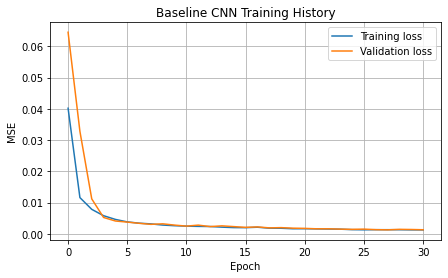

In [22]:
# %%
plt.figure(figsize=(7, 4))
plt.plot(baseline_result["train_losses"], label="Training loss")
plt.plot(baseline_result["val_losses"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Baseline CNN Training History")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# ## 8. Experiment B: Leave-One-Variable-Out

In [24]:
# %%
leave_one_out_results = []

for removed_variable in variable_names:
    selected = [
        name for name in variable_names
        if name != removed_variable
    ]

    print(f"\nTraining model without: {removed_variable}")

    model, result = train_model(
        selected_variables=selected,
        verbose=False
    )

    val_mse = result["best_val_mse"]
    mse_increase = val_mse - baseline_mse

    leave_one_out_results.append(
        {
            "removed_variable": removed_variable,
            "n_variables": len(selected),
            "val_mse": val_mse,
            "mse_increase_from_baseline": mse_increase,
            "best_epoch": result["best_epoch"],
        }
    )

leave_one_out_df = pd.DataFrame(leave_one_out_results)
leave_one_out_df = leave_one_out_df.sort_values(
    "mse_increase_from_baseline",
    ascending=False
)

leave_one_out_df


Training model without: VImoistureDivergence

Training model without: VIwater

Training model without: CloudCover

Training model without: EvaporationRate

Training model without: SkinTemperature

Training model without: SeaLevelPressure

Training model without: 10mWindSpeed


,removed_variable,n_variables,val_mse,mse_increase_from_baseline,best_epoch
0,VImoistureDivergence,6,0.004124,0.002877,37
2,CloudCover,6,0.002007,0.000760,27
3,EvaporationRate,6,0.001861,0.000613,24
1,VIwater,6,0.001713,0.000465,37
6,10mWindSpeed,6,0.001435,0.000187,29
5,SeaLevelPressure,6,0.001397,0.000149,37
4,SkinTemperature,6,0.001141,-0.000107,48


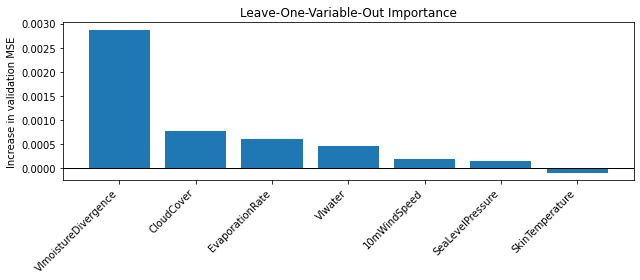

In [25]:
# %%
plt.figure(figsize=(9, 4))
plt.bar(
    leave_one_out_df["removed_variable"],
    leave_one_out_df["mse_increase_from_baseline"]
)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Increase in validation MSE")
plt.title("Leave-One-Variable-Out Importance")
plt.tight_layout()
plt.show()

In [26]:
# Interpretation:
#
# If removing a variable causes a large increase in validation MSE, that variable is likely important.

# ## 9. Experiment C: Single-Variable Models

In [27]:
# %%
single_variable_results = []

for variable in variable_names:
    print(f"\nTraining model with only: {variable}")

    model, result = train_model(
        selected_variables=[variable],
        verbose=False
    )

    single_variable_results.append(
        {
            "variable": variable,
            "n_variables": 1,
            "val_mse": result["best_val_mse"],
            "best_epoch": result["best_epoch"],
        }
    )

single_variable_df = pd.DataFrame(single_variable_results)
single_variable_df = single_variable_df.sort_values(
    "val_mse",
    ascending=True
)

single_variable_df


Training model with only: VImoistureDivergence

Training model with only: VIwater

Training model with only: CloudCover

Training model with only: EvaporationRate

Training model with only: SkinTemperature

Training model with only: SeaLevelPressure

Training model with only: 10mWindSpeed


,variable,n_variables,val_mse,best_epoch
0,VImoistureDivergence,1,0.001190,25
1,VIwater,1,0.002921,31
6,10mWindSpeed,1,0.003875,28
3,EvaporationRate,1,0.004463,19
5,SeaLevelPressure,1,0.004639,20
2,CloudCover,1,0.004798,11
4,SkinTemperature,1,0.005957,17


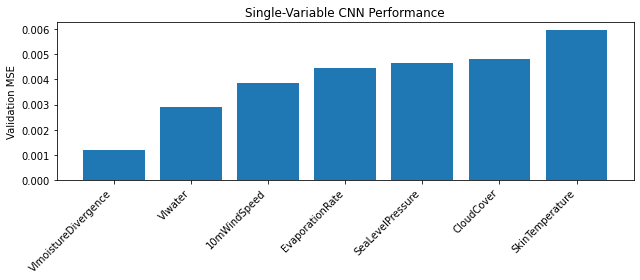

In [28]:
# %%
plt.figure(figsize=(9, 4))
plt.bar(
    single_variable_df["variable"],
    single_variable_df["val_mse"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation MSE")
plt.title("Single-Variable CNN Performance")
plt.tight_layout()
plt.show()

In [29]:
# %% [markdown]
# Interpretation:
#
# A lower validation MSE means that the variable alone contains more rainfall-relevant information.

# %% [markdown]
# ## 10. Experiment D: Permutation Importance
#
# This uses the trained all-variable baseline model.
# One variable is shuffled across the validation samples while the others are kept unchanged.

In [30]:
# %%
def evaluate_tensor(model, x_tensor, y_tensor, criterion, device):
    model.eval()

    x_tensor = x_tensor.to(device)
    y_tensor = y_tensor.to(device)

    with torch.no_grad():
        predictions = model(x_tensor)
        loss = criterion(predictions, y_tensor)

    return loss.item()

In [31]:
# %%
criterion = nn.MSELoss()

x_val_tensor = baseline_result["x_val_tensor"]
y_val_tensor = baseline_result["y_val_tensor"]

baseline_val_mse_check = evaluate_tensor(
    baseline_model,
    x_val_tensor,
    y_val_tensor,
    criterion,
    device
)

print("Baseline validation MSE check:", baseline_val_mse_check)

Baseline validation MSE check: 0.0012477642158046365


In [32]:
# %%
permutation_results = []

for channel_index, variable in enumerate(variable_names):
    x_permuted = x_val_tensor.clone()

    # Shuffle validation samples along time/sample dimension.
    # Spatial structure within each field is preserved.
    permutation = torch.randperm(x_permuted.shape[0])

    x_permuted[:, channel_index, :, :] = x_permuted[
        permutation,
        channel_index,
        :, :
    ]

    permuted_mse = evaluate_tensor(
        baseline_model,
        x_permuted,
        y_val_tensor,
        criterion,
        device
    )

    mse_increase = permuted_mse - baseline_val_mse_check

    permutation_results.append(
        {
            "variable": variable,
            "permuted_val_mse": permuted_mse,
            "mse_increase_from_baseline": mse_increase,
        }
    )

permutation_df = pd.DataFrame(permutation_results)
permutation_df = permutation_df.sort_values(
    "mse_increase_from_baseline",
    ascending=False
)

permutation_df

,variable,permuted_val_mse,mse_increase_from_baseline
0,VImoistureDivergence,0.012690,0.011443
3,EvaporationRate,0.001618,0.000370
1,VIwater,0.001603,0.000356
2,CloudCover,0.001591,0.000344
4,SkinTemperature,0.001393,0.000146
6,10mWindSpeed,0.001362,0.000114
5,SeaLevelPressure,0.001264,0.000017


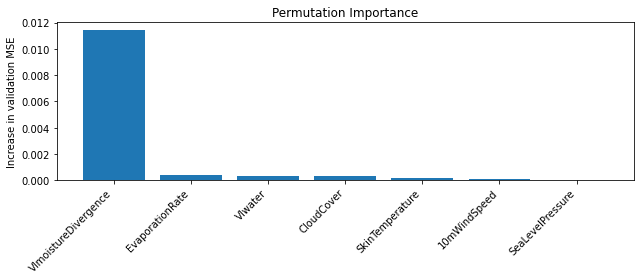

In [33]:
# %%
plt.figure(figsize=(9, 4))
plt.bar(
    permutation_df["variable"],
    permutation_df["mse_increase_from_baseline"]
)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Increase in validation MSE")
plt.title("Permutation Importance")
plt.tight_layout()
plt.show()

In [34]:

# ## 11. Combine Results into One Summary Table

In [35]:
# %%
summary_df = pd.DataFrame({
    "variable": variable_names
})

summary_df = summary_df.merge(
    single_variable_df[["variable", "val_mse"]],
    on="variable",
    how="left"
).rename(
    columns={"val_mse": "single_variable_val_mse"}
)

summary_df = summary_df.merge(
    leave_one_out_df[
        ["removed_variable", "val_mse", "mse_increase_from_baseline"]
    ],
    left_on="variable",
    right_on="removed_variable",
    how="left"
).drop(
    columns=["removed_variable"]
).rename(
    columns={
        "val_mse": "leave_one_out_val_mse",
        "mse_increase_from_baseline": "leave_one_out_mse_increase"
    }
)

summary_df = summary_df.merge(
    permutation_df[
        ["variable", "permuted_val_mse", "mse_increase_from_baseline"]
    ],
    on="variable",
    how="left"
).rename(
    columns={
        "mse_increase_from_baseline": "permutation_mse_increase"
    }
)

summary_df

,variable,single_variable_val_mse,leave_one_out_val_mse,leave_one_out_mse_increase,permuted_val_mse,permutation_mse_increase
0,VImoistureDivergence,0.001190,0.004124,0.002877,0.012690,0.011443
1,VIwater,0.002921,0.001713,0.000465,0.001603,0.000356
2,CloudCover,0.004798,0.002007,0.000760,0.001591,0.000344
3,EvaporationRate,0.004463,0.001861,0.000613,0.001618,0.000370
4,SkinTemperature,0.005957,0.001141,-0.000107,0.001393,0.000146
5,SeaLevelPressure,0.004639,0.001397,0.000149,0.001264,0.000017
6,10mWindSpeed,0.003875,0.001435,0.000187,0.001362,0.000114


In [36]:
# %%
# Optional: save results as CSV

OUTPUT_DIR = Path("/Users/camus/Desktop/dissertation/meeting1/RainfallWestAfrica_Resources")
summary_path = OUTPUT_DIR / "variable_importance_summary.csv"

summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: /Users/camus/Desktop/dissertation/meeting1/RainfallWestAfrica_Resources/variable_importance_summary.csv


In [37]:
# ## 12. Plot Combined Importance Comparison

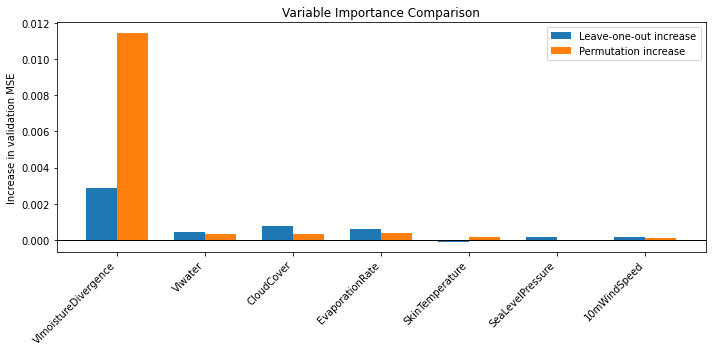

In [38]:
# %%
plot_df = summary_df.copy()

plt.figure(figsize=(10, 5))

x = np.arange(len(plot_df))
width = 0.35

plt.bar(
    x - width / 2,
    plot_df["leave_one_out_mse_increase"],
    width,
    label="Leave-one-out increase"
)

plt.bar(
    x + width / 2,
    plot_df["permutation_mse_increase"],
    width,
    label="Permutation increase"
)

plt.axhline(0, color="black", linewidth=1)
plt.xticks(x, plot_df["variable"], rotation=45, ha="right")
plt.ylabel("Increase in validation MSE")
plt.title("Variable Importance Comparison")
plt.legend()
plt.tight_layout()
plt.show()